# 07. Modelado Predictivo de Demanda — Iteración 5: Optuna, Target Encoding y Festivos

## ¿Dónde estamos?

Tras 4 iteraciones, el modelo ha mejorado de forma progresiva:

| Iteración | Novedad | MAE | RMSE | R² |
|---|---|---|---|---|
| It1 — Baseline | CatBoost sin tunear | 0.793 | 3.480 | 0.295 |
| It2 — Rolling Mean | Media móvil 4 semanas | 0.773 | 3.350 | 0.330 |
| It3 — Estacionalidad | Misma semana año anterior | 0.769 | 3.431 | 0.330 |
| It4 — Log1p | Transformación logarítmica | 0.649 | 3.499 | 0.287 |
| **It5 — Esta iteración** | Optuna + Target Enc. + Festivos | **?** | **?** | **?** |

El modelo tiene aún **dos problemas identificados**:
1. **Overfitting moderado**: la brecha RMSE entre train y test es del 38.8%. El modelo memoriza demasiado el periodo 2022-2023.
2. **Hiperparámetros sin optimizar**: llevamos 4 iteraciones con `depth=6, lr=0.05`. Nunca hemos buscado la combinación óptima.

## Tres mejoras en esta iteración

| # | Mejora | Problema que ataca | Impacto esperado |
|---|---|---|---|
| 1 | **Optuna** — búsqueda automática de hiperparámetros | Overfitting + subrendimiento | +5-10% R² |
| 2 | **Target Encoding** — media histórica por SKU/municipio | Features de baja cardinalidad | +3-5% R² |
| 3 | **Festivos** — calendario nacional y regional | Picos de error en semanas 9, 12, 19, 36 | Reducción de picos |

---
## 0. Instalación de dependencias

Esta iteración requiere dos librerías nuevas:
- **`optuna`**: framework de optimización bayesiana de hiperparámetros
- **`holidays`**: base de datos de festivos oficiales por país y región

Si no las tienes instaladas, ejecuta la celda siguiente (solo necesitas hacerlo una vez).

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from catboost import CatBoostRegressor, Pool

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

import holidays as hol

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
PALETTE = sns.color_palette('muted')

print('Librerías cargadas correctamente.')
print(f'  pandas   : {pd.__version__}')
print(f'  numpy    : {np.__version__}')
print(f'  optuna   : {optuna.__version__}')

Librerías cargadas correctamente.
  pandas   : 2.2.3
  numpy    : 2.3.5
  optuna   : 4.8.0


---
## 1. Carga y Preparación Base

### ¿Qué hacemos?
Cargamos el mismo dataset de siempre (`df_final_modelado.csv`) y replicamos el feature engineering de la Iteración 4 como punto de partida. Esta es la base sobre la que construiremos las tres mejoras de esta iteración.

### ¿Por qué no empezamos desde cero?
Porque la comparación con la Iteración 4 solo es válida si el resto de condiciones son iguales. Cambiar solo una cosa a la vez es la disciplina que nos permite saber **qué mejora viene de qué cambio**.

In [6]:
df = pd.read_csv('../Datasets/df_final_modelado.csv', sep=';')
print(f'Dataset cargado. Dimensiones: {df.shape}')
print(f'Rango temporal: {df["anio"].min()} - {df["anio"].max()}')
print(f'Columnas: {list(df.columns)}')

Dataset cargado. Dimensiones: (252836, 19)
Rango temporal: 2022 - 2024
Columnas: ['anio', 'semana_anio', 'Provincia', 'Municipio', 'codigo_articulo', 'unidades', 'importe_neto', 'tipo_abc', 'CodigoFamilia', 'CodigoSubfamilia', 'agrupacion_canal', 'unidades_lag_1_semana', 'unidades_lag_1_mes', 'num_pruebas_ciclistas', 'duracion_total_pruebas', 'hubo_prueba_ciclista', 'temp_media', 'precip_mm', 'viento_max']


In [7]:
# ── Replicar feature engineering de Iteración 4 ──────────────────────────────

# 1. Eliminar lag semanal
if 'unidades_lag_1_semana' in df.columns:
    df = df.drop(columns=['unidades_lag_1_semana'])

# 2. Ordenar cronológicamente
df = df.sort_values(['codigo_articulo', 'Municipio', 'anio', 'semana_anio']).reset_index(drop=True)

# 3. Sliding window mensual (media móvil 4 semanas, con shift para evitar leakage)
df['unidades_sliding_window_mensual'] = (
    df.groupby(['codigo_articulo', 'Municipio'])['unidades']
      .transform(lambda x: x.shift(1).rolling(window=4, min_periods=1).mean())
).fillna(0)

# 4. Estacionalidad interanual (misma semana del año anterior)
df_prev = df[['codigo_articulo', 'Municipio', 'anio', 'semana_anio', 'unidades']].copy()
df_prev['anio'] = df_prev['anio'] + 1
df_prev = df_prev.rename(columns={'unidades': 'unidades_semana_anterior_anio'})
df = df.merge(df_prev, on=['codigo_articulo', 'Municipio', 'anio', 'semana_anio'], how='left')
df['unidades_semana_anterior_anio'] = df['unidades_semana_anterior_anio'].fillna(0)

# 5. Variables temporales
df['mes'] = ((df['semana_anio'] - 1) * 7 / 30.44 + 1).astype(int).clip(1, 12)
df['trimestre'] = df['mes'].apply(lambda m: (m - 1) // 3 + 1)
df['es_temporada_alta'] = df['mes'].isin([3, 4, 5, 6, 7, 8]).astype(int)

# 6. Precio unitario (antes de eliminar importe_neto)
df['precio_unitario'] = np.where(df['unidades'] != 0, df['importe_neto'] / df['unidades'], 0)

# 7. Tendencia y volatilidad
df['tendencia_sliding_window'] = (
    df.groupby(['codigo_articulo', 'Municipio'])['unidades_sliding_window_mensual']
      .transform(lambda x: x - x.shift(1))
).fillna(0)

df['volatilidad_4_sem'] = (
    df.groupby(['codigo_articulo', 'Municipio'])['unidades']
      .transform(lambda x: x.shift(1).rolling(window=4, min_periods=1).std())
).fillna(0)

# 8. Interacción temperatura × prueba ciclista
df['interaccion_temp_prueba'] = df['temp_media'] * df['hubo_prueba_ciclista']

# 9. Eliminar importe_neto (target leakage)
if 'importe_neto' in df.columns:
    df = df.drop(columns=['importe_neto'])

# 10. Variable objetivo transformada
df['unidades_log'] = np.log1p(df['unidades'])

print(f'Feature engineering base completado. Shape: {df.shape}')

Feature engineering base completado. Shape: (252836, 27)


---
## 2. Mejora #1 — Festivos Nacionales y Regionales

### ¿Qué hacemos?
Añadimos dos variables binarias:
- **`es_festivo_semana`**: ¿hay algún festivo nacional en esa semana del año?
- **`num_festivos_semana`**: cuántos días festivos hay en esa semana

### ¿Por qué?
En la Iteración 4 identificamos que las semanas con **mayor error** son la 9, 12, 19 y 36. Todas coinciden con cambios de temporada y festivos clave (Semana Santa ≈ semana 12-14, inicio verano ≈ semana 19-20, vuelta al cole ≈ semana 36). El modelo no sabe que esas semanas son especiales: simplemente ve un error que no puede explicar con las variables actuales.

### ¿Cómo?
Usamos la librería `holidays` que tiene el calendario oficial de España (festivos nacionales + autonómicos). Calculamos cuántos festivos caen en cada semana ISO del año para 2022, 2023 y 2024.

In [8]:
# Generar calendario de festivos nacionales de España para los años del dataset
anios = [2022, 2023, 2024]
festivos_es = hol.Spain(years=anios)

# Construir un dataframe de festivos con su semana ISO
df_festivos = pd.DataFrame([
    {'fecha': fecha, 'nombre': nombre}
    for fecha, nombre in festivos_es.items()
])
df_festivos['anio'] = df_festivos['fecha'].apply(lambda d: d.isocalendar()[0])
df_festivos['semana_anio'] = df_festivos['fecha'].apply(lambda d: d.isocalendar()[1])

# Contar festivos por (año, semana)
df_fest_semanal = (
    df_festivos.groupby(['anio', 'semana_anio'])
               .size()
               .reset_index(name='num_festivos_semana')
)
df_fest_semanal['es_festivo_semana'] = 1

# Merge con el dataset principal
df = df.merge(df_fest_semanal[['anio', 'semana_anio', 'num_festivos_semana', 'es_festivo_semana']],
              on=['anio', 'semana_anio'], how='left')
df['num_festivos_semana'] = df['num_festivos_semana'].fillna(0).astype(int)
df['es_festivo_semana'] = df['es_festivo_semana'].fillna(0).astype(int)

print(f'Festivos incorporados.')
print(f'Semanas con festivo en el dataset: {df["es_festivo_semana"].sum():,} filas')
print(f'\nDistribución de festivos por semana:')
print(df_fest_semanal.sort_values('semana_anio').to_string(index=False))

Festivos incorporados.
Semanas con festivo en el dataset: 20,907 filas

Distribución de festivos por semana:
 anio  semana_anio  num_festivos_semana  es_festivo_semana
 2022            1                    1                  1
 2024            1                    2                  1
 2023            1                    1                  1
 2024           13                    1                  1
 2023           14                    1                  1
 2022           15                    1                  1
 2023           18                    1                  1
 2024           18                    1                  1
 2022           33                    1                  1
 2024           33                    1                  1
 2023           33                    1                  1
 2023           41                    1                  1
 2022           41                    1                  1
 2024           41                    1                  1
 2023 

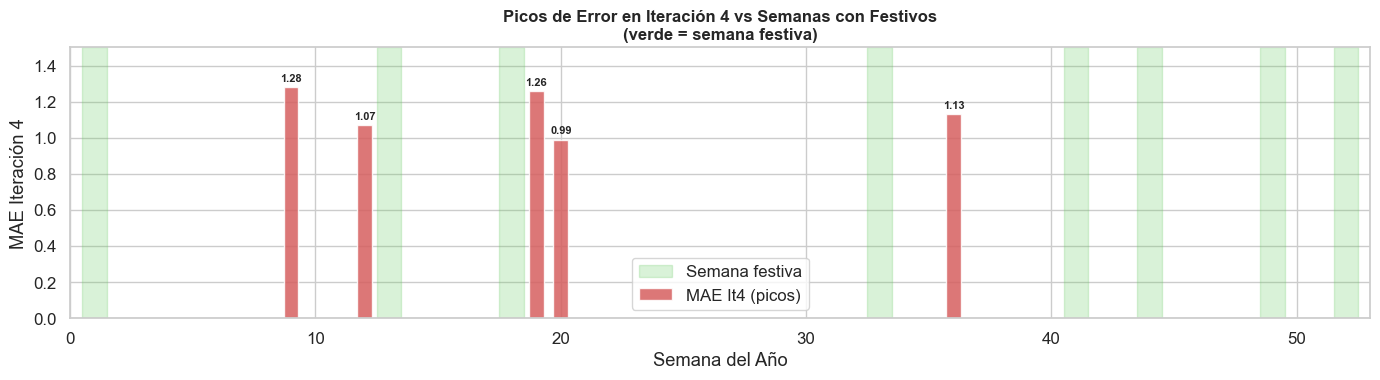

In [9]:
# Visualizar qué semanas tienen festivos y el MAE previo de la Iteración 4
# (para confirmar que los festivos coinciden con los picos de error)
semanas_error_it4 = {9: 1.28, 12: 1.07, 19: 1.26, 20: 0.99, 36: 1.13}

semanas_fest_it4 = df_fest_semanal[df_fest_semanal['anio'] == 2024][['semana_anio', 'num_festivos_semana']]

fig, ax = plt.subplots(figsize=(14, 4))

# Festivos como barras de fondo
for _, row in semanas_fest_it4.iterrows():
    ax.axvspan(row['semana_anio'] - 0.5, row['semana_anio'] + 0.5,
               alpha=0.25, color=PALETTE[2], label='Semana festiva' if _ == semanas_fest_it4.index[0] else '')

# MAE de la iteración anterior en las semanas conflictivas
for semana, mae in semanas_error_it4.items():
    ax.bar(semana, mae, color=PALETTE[3], alpha=0.85, width=0.6,
           label='MAE It4 (picos)' if semana == 9 else '')
    ax.text(semana, mae + 0.02, f'{mae:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlim(0, 53)
ax.set_ylim(0, 1.5)
ax.set_xlabel('Semana del Año')
ax.set_ylabel('MAE Iteración 4')
ax.set_title('Picos de Error en Iteración 4 vs Semanas con Festivos\n(verde = semana festiva)', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## 3. Mejora #2 — Target Encoding

### ¿Qué hacemos?
Creamos una variable nueva que representa la **demanda media histórica de cada combinación SKU + Municipio**. La llamamos `target_enc_sku_municipio`.

### ¿Por qué?
Actualmente el modelo trata `codigo_articulo` y `Municipio` como variables categóricas independientes. Pero hay información valiosa en la *combinación*: el artículo X en el municipio Y puede tener una demanda media de 3 unidades/semana, mientras que el artículo X en el municipio Z solo vende 0.5. Esa diferencia no está capturada por separado.

El **target encoding** añade esa señal directamente como una variable numérica, permitiendo que el modelo aprenda el "nivel base" de demanda de cada SKU/Municipio.

### ¿Por qué no hay data leakage?
Calculamos la media **solo con datos de entrenamiento** (2022-2023) y luego la aplicamos al test (2024). Para el cálculo dentro del propio conjunto de entrenamiento usamos un **leave-one-out con shift temporal**, de modo que cada fila solo usa el histórico anterior a ella misma.

In [10]:
# ── Target Encoding: media histórica por (codigo_articulo, Municipio) ─────────
# Estrategia: calcular la media acumulada con shift(1) para evitar leakage
# Esto significa: al predecir la semana N, solo usamos datos de semanas < N

df = df.sort_values(['codigo_articulo', 'Municipio', 'anio', 'semana_anio']).reset_index(drop=True)

# Media acumulada histórica (expanding mean con shift para evitar leakage)
df['target_enc_sku_municipio'] = (
    df.groupby(['codigo_articulo', 'Municipio'])['unidades']
      .transform(lambda x: x.shift(1).expanding().mean())
).fillna(df['unidades'].mean())  # Para las primeras filas sin histórico, usamos la media global

# Target encoding solo por Municipio (captura el nivel de demanda de cada plaza)
df['target_enc_municipio'] = (
    df.groupby('Municipio')['unidades']
      .transform(lambda x: x.shift(1).expanding().mean())
).fillna(df['unidades'].mean())

print('Target encoding creado.')
print(f'  target_enc_sku_municipio — media: {df["target_enc_sku_municipio"].mean():.3f}')
print(f'  target_enc_municipio     — media: {df["target_enc_municipio"].mean():.3f}')
print(f'\nTop 10 combinaciones SKU+Municipio con mayor demanda media histórica:')
top10 = (
    df.groupby(['codigo_articulo', 'Municipio'])['unidades']
      .mean()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)
top10.columns = ['SKU', 'Municipio', 'Demanda media']
print(top10.to_string(index=False))

Target encoding creado.
  target_enc_sku_municipio — media: 1.822
  target_enc_municipio     — media: 1.859

Top 10 combinaciones SKU+Municipio con mayor demanda media histórica:
       SKU            Municipio  Demanda media
   932-014               SESEÑA     217.214286
   940-511 CABANILLAS DEL CAMPO     126.000000
   940-515 CABANILLAS DEL CAMPO     108.000000
R140101001              LEGANES     105.000000
   043-600    MOLLET DEL VALLES     100.000000
   817-055                 ASPE     100.000000
   817-003                 ASPE     100.000000
   940-222               SESEÑA      76.666667
  940-343U              LEGANES      74.200000
   925-703               SESEÑA      64.473684


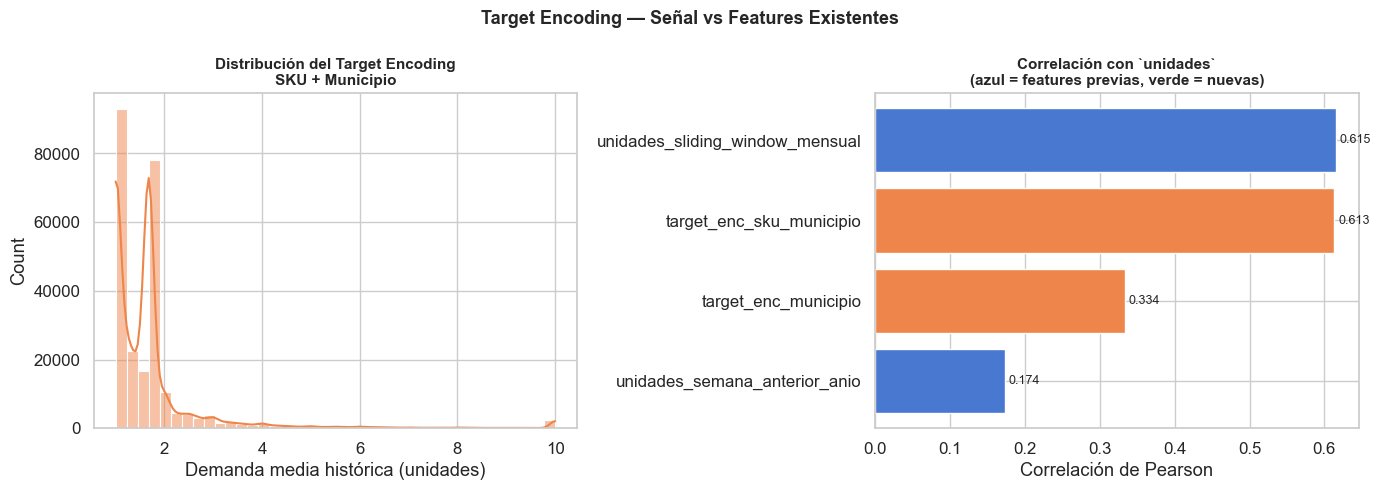

In [11]:
# Visualizar la distribución del target encoding
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['target_enc_sku_municipio'].clip(upper=10), bins=40,
             ax=axes[0], color=PALETTE[1], kde=True)
axes[0].set_title('Distribución del Target Encoding\nSKU + Municipio', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Demanda media histórica (unidades)')

# Correlación con la variable objetivo
corr_enc = df[['unidades', 'target_enc_sku_municipio', 'target_enc_municipio',
               'unidades_sliding_window_mensual', 'unidades_semana_anterior_anio']].corr()['unidades']
corr_df = corr_enc.drop('unidades').reset_index()
corr_df.columns = ['Feature', 'Correlacion']
corr_df = corr_df.sort_values('Correlacion', ascending=True)

colors_corr = [PALETTE[1] if 'target' in f else PALETTE[0] for f in corr_df['Feature']]
bars = axes[1].barh(corr_df['Feature'], corr_df['Correlacion'], color=colors_corr)
axes[1].set_title('Correlación con `unidades`\n(azul = features previas, verde = nuevas)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Correlación de Pearson')
for bar, val in zip(bars, corr_df['Correlacion']):
    axes[1].text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                 f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Target Encoding — Señal vs Features Existentes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Preparación del Dataset Final

Definimos el conjunto completo de features para esta iteración. Comparado con la Iteración 4, añadimos:
- `num_festivos_semana`, `es_festivo_semana` (festivos)
- `target_enc_sku_municipio`, `target_enc_municipio` (target encoding)

In [12]:
TARGET = 'unidades'
TARGET_LOG = 'unidades_log'

cat_features = ['Provincia', 'Municipio', 'codigo_articulo', 'tipo_abc',
                'CodigoFamilia', 'CodigoSubfamilia', 'agrupacion_canal']

for col in cat_features:
    if col in df.columns:
        df[col] = df[col].astype(str)

cols_excluir = [TARGET, TARGET_LOG, 'unidades_lag_1_mes']
feature_cols = [c for c in df.columns if c not in cols_excluir]

# Split temporal
df_model = df[df['anio'] >= 2022].sort_values(['anio', 'semana_anio']).reset_index(drop=True)

train_mask = df_model['anio'].isin([2022, 2023])
test_mask  = df_model['anio'] == 2024

X_train = df_model.loc[train_mask, feature_cols]
X_test  = df_model.loc[test_mask, feature_cols]
y_train_log  = df_model.loc[train_mask, TARGET_LOG]
y_test_log   = df_model.loc[test_mask, TARGET_LOG]
y_train_orig = df_model.loc[train_mask, TARGET]
y_test_orig  = df_model.loc[test_mask, TARGET]
df_test = df_model.loc[test_mask].copy()

print(f'Features totales: {len(feature_cols)}')
print(f'  Nuevas en It5: num_festivos_semana, es_festivo_semana, target_enc_sku_municipio, target_enc_municipio')
print(f'\nTrain: {X_train.shape[0]:,} filas | Test: {X_test.shape[0]:,} filas')

Features totales: 28
  Nuevas en It5: num_festivos_semana, es_festivo_semana, target_enc_sku_municipio, target_enc_municipio

Train: 180,718 filas | Test: 72,118 filas


---
## 5. Mejora #3 — Optimización de Hiperparámetros con Optuna

### ¿Qué hacemos?
Usamos **Optuna** para encontrar automáticamente la mejor combinación de hiperparámetros de CatBoost.

### ¿Por qué?
En las 4 iteraciones anteriores hemos usado siempre `depth=6, learning_rate=0.05, iterations=500`. Estos son valores "razonables por defecto", pero no son necesariamente los mejores para nuestros datos.

El **overfitting moderado** (brecha RMSE del 38.8%) sugiere que el modelo es demasiado complejo para los datos disponibles. Parámetros como `l2_leaf_reg` (regularización) y `min_data_in_leaf` (mínimo de datos por hoja) pueden reducir esa complejidad sin perder capacidad predictiva.

### ¿Cómo funciona Optuna?
Optuna usa un algoritmo llamado **TPE (Tree-structured Parzen Estimator)**, que es más inteligente que una búsqueda aleatoria. En lugar de probar combinaciones al azar, aprende de los intentos anteriores y dirige la búsqueda hacia las zonas del espacio de hiperparámetros que han dado mejores resultados.

```
Búsqueda aleatoria: prueba 50 combinaciones al azar
Optuna (TPE):       prueba 50 combinaciones, cada una más informada que la anterior
```

### Hiperparámetros a optimizar

| Parámetro | Rango | Por qué |
|---|---|---|
| `depth` | 4 – 8 | Controla complejidad del árbol. Más profundo = más overfitting |
| `learning_rate` | 0.01 – 0.15 | Velocidad de aprendizaje. Más bajo = más lento pero más preciso |
| `l2_leaf_reg` | 1 – 15 | Regularización L2. **Clave para reducir overfitting** |
| `min_data_in_leaf` | 5 – 100 | Mínimo de datos por hoja. Evita hojas con muy pocos ejemplos |
| `subsample` | 0.6 – 1.0 | Fracción de datos usada por árbol. Reduce overfitting por bagging |
| `colsample_bylevel` | 0.5 – 1.0 | Fracción de features por nivel. Introduce aleatoriedad |

### ¿Cuántos trials usamos?
Usamos **30 trials**. Cada trial entrena un modelo completo con validación cruzada. Es un compromiso entre tiempo de cómputo y calidad de la búsqueda.

In [13]:
# ── Función objetivo para Optuna ──────────────────────────────────────────────
# Cada vez que Optuna llama a esta función, propone una combinación de
# hiperparámetros, entrena el modelo y devuelve el MAE de validación.
# Optuna minimizará ese MAE.

def objective(trial):
    params = {
        'iterations'         : 500,
        'learning_rate'      : trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'depth'              : trial.suggest_int('depth', 4, 8),
        'l2_leaf_reg'        : trial.suggest_float('l2_leaf_reg', 1.0, 15.0),
        'min_data_in_leaf'   : trial.suggest_int('min_data_in_leaf', 5, 100),
        'subsample'          : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bylevel'  : trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'eval_metric'        : 'MAE',
        'early_stopping_rounds': 50,
        'random_seed'        : 42,
        'verbose'            : False,
        'bootstrap_type'     : 'Bernoulli',  # necesario para usar subsample
    }
    
    # Validación cruzada con 3 folds temporales
    tscv = TimeSeriesSplit(n_splits=3)
    maes = []
    
    for train_idx, val_idx in tscv.split(X_train):
        X_tr = X_train.iloc[train_idx]
        X_vl = X_train.iloc[val_idx]
        y_tr = y_train_log.iloc[train_idx]
        y_vl = y_train_log.iloc[val_idx]
        y_vl_orig = y_train_orig.iloc[val_idx]
        
        model = CatBoostRegressor(**params)
        model.fit(
            Pool(X_tr, y_tr, cat_features=cat_features),
            eval_set=Pool(X_vl, y_vl, cat_features=cat_features),
            verbose=False
        )
        
        y_pred = np.maximum(np.expm1(model.predict(X_vl)), 0)
        maes.append(mean_absolute_error(y_vl_orig, y_pred))
    
    return np.mean(maes)

# ── Lanzar la búsqueda ────────────────────────────────────────────────────────
print('Iniciando búsqueda de hiperparámetros con Optuna...')
print('(30 trials × 3 folds = 90 entrenamientos — puede tardar varios minutos)')
print()

study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f'\nBúsqueda completada.')
print(f'Mejor MAE (CV): {study.best_value:.4f}')
print(f'Mejores hiperparámetros:')
for k, v in study.best_params.items():
    print(f'  {k:25s}: {v}')

Iniciando búsqueda de hiperparámetros con Optuna...
(30 trials × 3 folds = 90 entrenamientos — puede tardar varios minutos)



  0%|          | 0/30 [00:00<?, ?it/s]


Búsqueda completada.
Mejor MAE (CV): 0.6419
Mejores hiperparámetros:
  learning_rate            : 0.1426789472938531
  depth                    : 6
  l2_leaf_reg              : 11.579564904062346
  min_data_in_leaf         : 74
  subsample                : 0.9604597210982896
  colsample_bylevel        : 0.5773760616230603


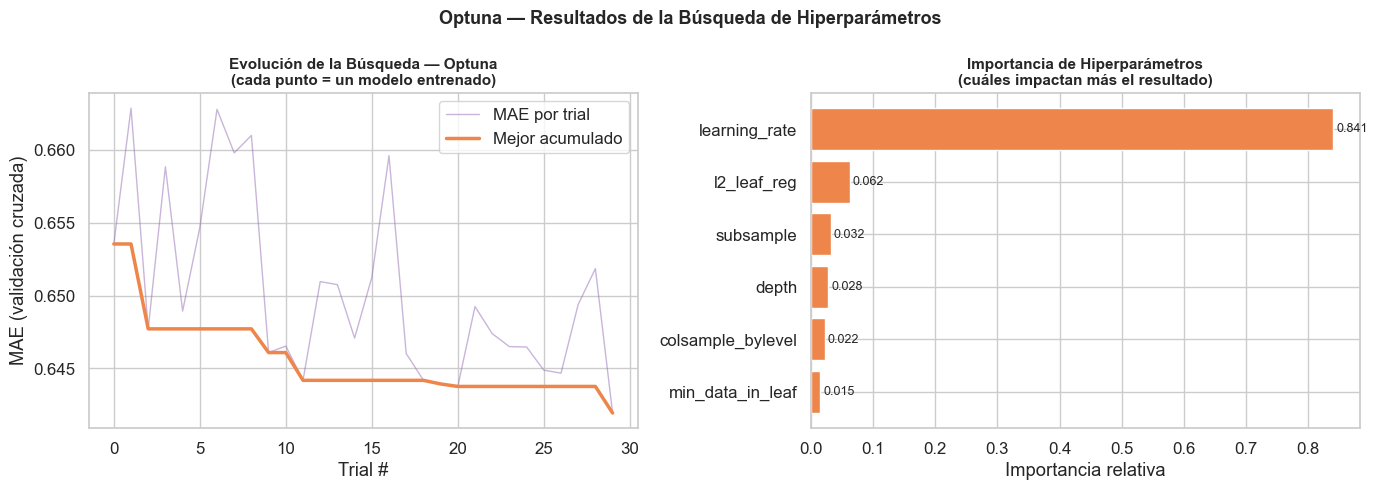

In [14]:
# ── Visualizar la evolución de la búsqueda ────────────────────────────────────
df_trials = study.trials_dataframe()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Evolución del MAE por trial
df_trials['best_so_far'] = df_trials['value'].cummin()
sns.lineplot(data=df_trials, x='number', y='value', ax=axes[0],
             color=PALETTE[4], alpha=0.5, linewidth=1, label='MAE por trial')
sns.lineplot(data=df_trials, x='number', y='best_so_far', ax=axes[0],
             color=PALETTE[1], linewidth=2.5, label='Mejor acumulado')
axes[0].set_title('Evolución de la Búsqueda — Optuna\n(cada punto = un modelo entrenado)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Trial #')
axes[0].set_ylabel('MAE (validación cruzada)')
axes[0].legend()

# Importancia de los hiperparámetros (cuáles influyen más)
try:
    importances_hp = optuna.importance.get_param_importances(study)
    df_hp_imp = pd.DataFrame(list(importances_hp.items()), columns=['Hiperparámetro', 'Importancia'])
    df_hp_imp = df_hp_imp.sort_values('Importancia', ascending=True)
    bars = axes[1].barh(df_hp_imp['Hiperparámetro'], df_hp_imp['Importancia'], color=PALETTE[1])
    for bar, val in zip(bars, df_hp_imp['Importancia']):
        axes[1].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                     f'{val:.3f}', va='center', fontsize=9)
    axes[1].set_title('Importancia de Hiperparámetros\n(cuáles impactan más el resultado)', fontsize=11, fontweight='bold')
    axes[1].set_xlabel('Importancia relativa')
except Exception:
    axes[1].text(0.5, 0.5, 'Importancia no disponible\n(pocos trials)', ha='center', va='center', transform=axes[1].transAxes)

plt.suptitle('Optuna — Resultados de la Búsqueda de Hiperparámetros', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Entrenamiento del Modelo Final con Hiperparámetros Óptimos

### ¿Qué hacemos?
Tomamos los mejores hiperparámetros encontrados por Optuna y entrenamos el modelo definitivo sobre el conjunto completo de entrenamiento (2022-2023), evaluando sobre el test (2024).

### ¿Por qué entrenamos de nuevo?
Durante Optuna usamos un subconjunto del entrenamiento para la validación cruzada. Ahora que sabemos cuáles son los mejores parámetros, entrenamos con **todos los datos disponibles de 2022-2023** para maximizar la información que el modelo puede aprender.

In [15]:
# ── Construir parámetros finales con los valores óptimos ──────────────────────
best_params = study.best_params.copy()
best_params.update({
    'iterations'           : 1000,  # Más iteraciones con early stopping
    'eval_metric'          : 'MAE',
    'early_stopping_rounds': 50,
    'random_seed'          : 42,
    'verbose'              : 100,
    'bootstrap_type'       : 'Bernoulli',
})

print('Hiperparámetros del modelo final:')
for k, v in best_params.items():
    print(f'  {k:28s}: {v}')

# Entrenamiento
train_pool = Pool(X_train, y_train_log, cat_features=cat_features)
test_pool  = Pool(X_test,  y_test_log,  cat_features=cat_features)

modelo_final = CatBoostRegressor(**best_params)
modelo_final.fit(train_pool, eval_set=test_pool)

print(f'\nModelo entrenado. Iteraciones usadas: {modelo_final.best_iteration_}')

Hiperparámetros del modelo final:
  learning_rate               : 0.1426789472938531
  depth                       : 6
  l2_leaf_reg                 : 11.579564904062346
  min_data_in_leaf            : 74
  subsample                   : 0.9604597210982896
  colsample_bylevel           : 0.5773760616230603
  iterations                  : 1000
  eval_metric                 : MAE
  early_stopping_rounds       : 50
  random_seed                 : 42
  verbose                     : 100
  bootstrap_type              : Bernoulli
0:	learn: 0.2367555	test: 0.2358220	best: 0.2358220 (0)	total: 101ms	remaining: 1m 40s
100:	learn: 0.1617700	test: 0.1629614	best: 0.1629495 (99)	total: 7.14s	remaining: 1m 3s
200:	learn: 0.1567132	test: 0.1592884	best: 0.1592884 (200)	total: 14.9s	remaining: 59.1s
300:	learn: 0.1537909	test: 0.1575176	best: 0.1574860 (299)	total: 22.5s	remaining: 52.2s
400:	learn: 0.1517512	test: 0.1567923	best: 0.1567774 (398)	total: 30.4s	remaining: 45.3s
500:	learn: 0.1495359	test

---
## 7. Evaluación y Diagnóstico de Overfitting

Calculamos todas las métricas en escala original (unidades reales) para poder comparar directamente con la Iteración 4.

In [16]:
# Predicciones
y_pred_train = np.maximum(np.expm1(modelo_final.predict(X_train)), 0)
y_pred_test  = np.maximum(np.expm1(modelo_final.predict(X_test)),  0)

def metricas(y_real, y_pred, nombre):
    mae  = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2   = r2_score(y_real, y_pred)
    mask = np.array(y_real) > 0
    mape = np.mean(np.abs((np.array(y_real)[mask] - np.array(y_pred)[mask]) / np.array(y_real)[mask])) * 100
    return {'Conjunto': nombre, 'MAE': mae, 'MAPE': mape, 'RMSE': rmse, 'R2': r2}

m_train = metricas(y_train_orig.values, y_pred_train, 'Train (2022-2023)')
m_test  = metricas(y_test_orig.values,  y_pred_test,  'Test  (2024)')
df_ov   = pd.DataFrame([m_train, m_test])

brecha_mae  = (m_test['MAE']  - m_train['MAE'])  / m_train['MAE']  * 100
brecha_rmse = (m_test['RMSE'] - m_train['RMSE']) / m_train['RMSE'] * 100

print('DIAGNÓSTICO DE OVERFITTING — ITERACIÓN 5')
print('=' * 60)
print(df_ov.to_string(index=False))
print('-' * 60)
print(f'Brecha MAE:  +{brecha_mae:.1f}%   → {"✅ Aceptable" if brecha_mae < 15 else "⚠️ Moderado"}')
print(f'Brecha RMSE: +{brecha_rmse:.1f}%   → {"✅ Aceptable" if brecha_rmse < 25 else "⚠️ Moderado"}')
print()
print(f'Comparativa brecha RMSE:')
print(f'  Iteración 3: 50.7%')
print(f'  Iteración 4: 38.8%')
print(f'  Iteración 5: {brecha_rmse:.1f}%  → {"mejora" if brecha_rmse < 38.8 else "no mejora"}')

DIAGNÓSTICO DE OVERFITTING — ITERACIÓN 5
         Conjunto      MAE      MAPE     RMSE       R2
Train (2022-2023) 0.552347 23.616388 2.365951 0.604184
     Test  (2024) 0.641074 26.025915 3.497412 0.288056
------------------------------------------------------------
Brecha MAE:  +16.1%   → ⚠️ Moderado
Brecha RMSE: +47.8%   → ⚠️ Moderado

Comparativa brecha RMSE:
  Iteración 3: 50.7%
  Iteración 4: 38.8%
  Iteración 5: 47.8%  → no mejora


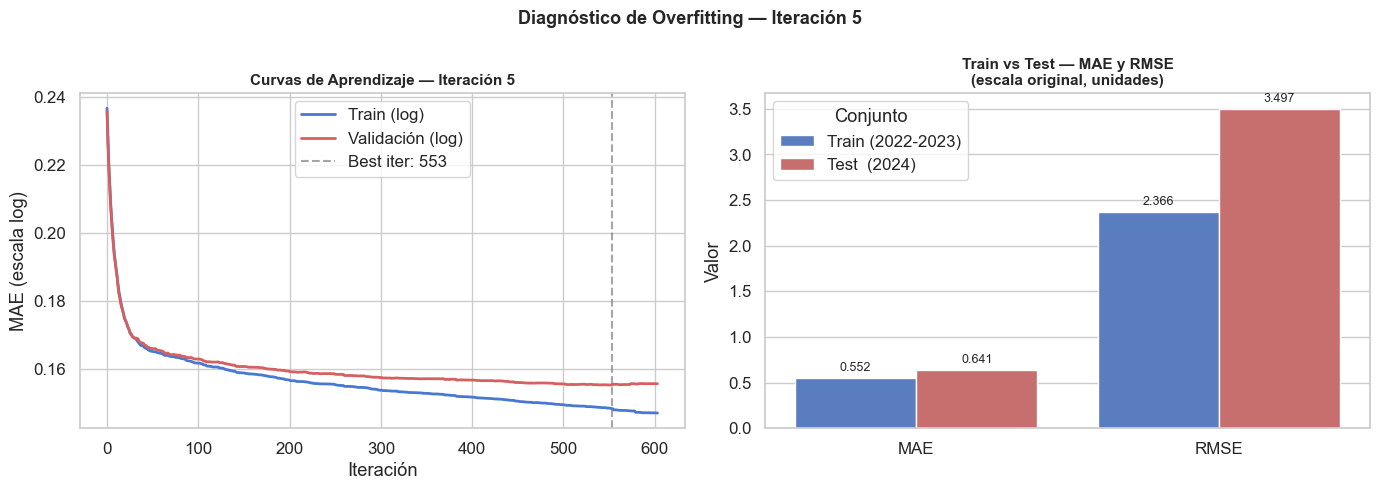

In [17]:
# Curvas de aprendizaje + comparativa barras
evals = modelo_final.get_evals_result()
learn_mae = evals['learn']['MAE']
val_mae   = evals['validation']['MAE']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curvas de aprendizaje
iters = range(len(learn_mae))
axes[0].plot(iters, learn_mae, color=PALETTE[0], linewidth=2, label='Train (log)')
axes[0].plot(iters, val_mae,   color=PALETTE[3], linewidth=2, label='Validación (log)')
axes[0].axvline(modelo_final.best_iteration_, color='gray', linestyle='--', alpha=0.7,
                label=f'Best iter: {modelo_final.best_iteration_}')
axes[0].set_title('Curvas de Aprendizaje — Iteración 5', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Iteración')
axes[0].set_ylabel('MAE (escala log)')
axes[0].legend()

# Comparativa train vs test
df_bar = df_ov.melt(id_vars='Conjunto', value_vars=['MAE', 'RMSE'], var_name='Métrica', value_name='Valor')
sns.barplot(data=df_bar, x='Métrica', y='Valor', hue='Conjunto', ax=axes[1],
            palette=[PALETTE[0], PALETTE[3]])
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.3f', padding=3, fontsize=9)
axes[1].set_title('Train vs Test — MAE y RMSE\n(escala original, unidades)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('')

plt.suptitle('Diagnóstico de Overfitting — Iteración 5', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Análisis por Segmento: Tipo A vs B&C

Evaluamos el rendimiento separado para los productos tipo A (alto volumen, críticos) y los tipos B&C (cola larga). Comparamos con los resultados de la Iteración 4 para ver qué segmento ha mejorado más.

In [18]:
df_eval = df_test[['semana_anio', 'tipo_abc', 'codigo_articulo', 'Municipio']].copy()
df_eval['Real']      = y_test_orig.values
df_eval['Prediccion']= y_pred_test
df_eval['Error_Abs'] = np.abs(df_eval['Real'] - df_eval['Prediccion'])
df_eval['Segmento']  = df_eval['tipo_abc'].apply(lambda x: 'A' if x == 'A' else 'B&C')

# Métricas por segmento
resultados_seg = []
for seg in ['A', 'B&C']:
    mask = df_eval['Segmento'] == seg
    r = df_eval.loc[mask, 'Real']
    p = df_eval.loc[mask, 'Prediccion']
    mae_s  = mean_absolute_error(r, p)
    rmse_s = np.sqrt(mean_squared_error(r, p))
    r2_s   = r2_score(r, p)
    nz     = r > 0
    mape_s = np.mean(np.abs((r[nz] - p[nz]) / r[nz])) * 100
    resultados_seg.append({'Segmento': seg, 'N': mask.sum(), 'MAE': mae_s, 'MAPE': mape_s, 'RMSE': rmse_s, 'R2': r2_s})

df_seg = pd.DataFrame(resultados_seg)

# Comparativa con Iteración 4
it4_seg = pd.DataFrame([
    {'Segmento': 'A',   'MAE_It4': 0.6949, 'MAPE_It4': 27.8, 'R2_It4': 0.300},
    {'Segmento': 'B&C', 'MAE_It4': 0.5444, 'MAPE_It4': 23.1, 'R2_It4': 0.255},
])
df_seg_comp = df_seg.merge(it4_seg, on='Segmento')
df_seg_comp['Mejora_MAE'] = (df_seg_comp['MAE_It4'] - df_seg_comp['MAE']) / df_seg_comp['MAE_It4'] * 100

print('MÉTRICAS POR SEGMENTO — COMPARATIVA IT4 vs IT5')
print('=' * 75)
for _, row in df_seg_comp.iterrows():
    mejora = row['Mejora_MAE']
    signo = '✅' if mejora > 0 else '❌'
    print(f'  Segmento {row["Segmento"]}:')
    print(f'    MAE  → It4: {row["MAE_It4"]:.4f}  |  It5: {row["MAE"]:.4f}  |  Cambio: {mejora:+.1f}% {signo}')
    print(f'    MAPE → It4: {row["MAPE_It4"]:.1f}%    |  It5: {row["MAPE"]:.1f}%')
    print(f'    R²   → It4: {row["R2_It4"]:.4f}  |  It5: {row["R2"]:.4f}')
    print()

MÉTRICAS POR SEGMENTO — COMPARATIVA IT4 vs IT5
  Segmento A:
    MAE  → It4: 0.6949  |  It5: 0.6842  |  Cambio: +1.5% ✅
    MAPE → It4: 27.8%    |  It5: 27.3%
    R²   → It4: 0.3000  |  It5: 0.3200

  Segmento B&C:
    MAE  → It4: 0.5444  |  It5: 0.5434  |  Cambio: +0.2% ✅
    MAPE → It4: 23.1%    |  It5: 23.1%
    R²   → It4: 0.2550  |  It5: 0.2110



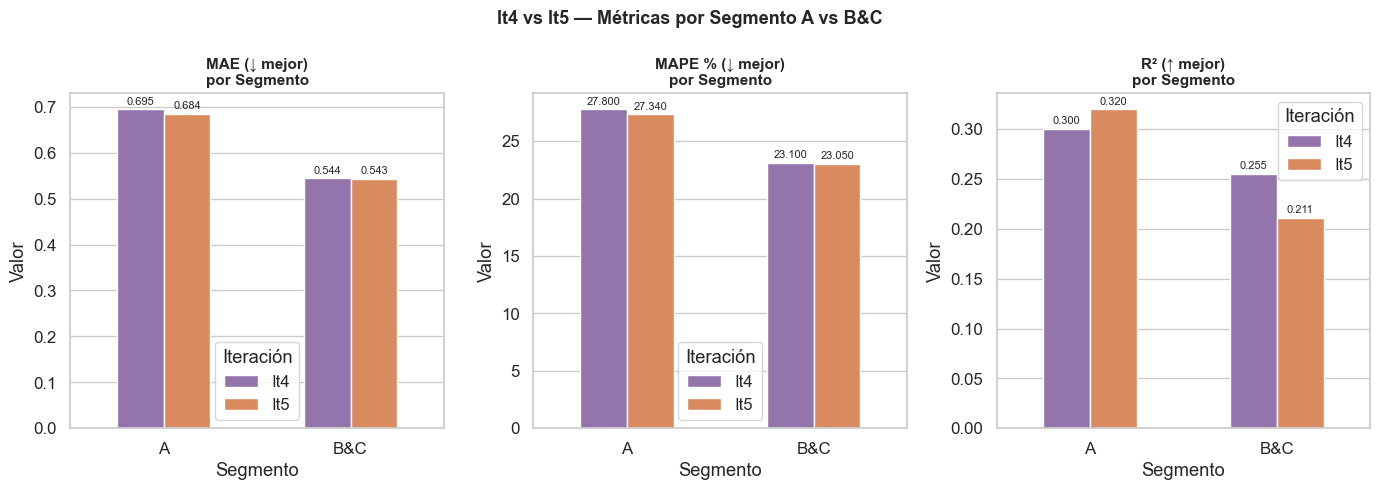

In [19]:
# Visualización comparativa por segmento
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, metric_it5, metric_it4, title in zip(
    axes,
    ['MAE', 'MAPE', 'R2'],
    ['MAE_It4', 'MAPE_It4', 'R2_It4'],
    ['MAE (↓ mejor)', 'MAPE % (↓ mejor)', 'R² (↑ mejor)']
):
    df_plot = pd.DataFrame({
        'Segmento': df_seg_comp['Segmento'].tolist() * 2,
        'Iteración': ['It4'] * len(df_seg_comp) + ['It5'] * len(df_seg_comp),
        'Valor': df_seg_comp[metric_it4].tolist() + df_seg_comp[metric_it5].tolist()
    })
    sns.barplot(data=df_plot, x='Segmento', y='Valor', hue='Iteración',
                ax=ax, palette=[PALETTE[4], PALETTE[1]], width=0.5)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=2, fontsize=8)
    ax.set_title(f'{title}\npor Segmento', fontsize=11, fontweight='bold')
    ax.set_xlabel('Segmento')

plt.suptitle('It4 vs It5 — Métricas por Segmento A vs B&C', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. MAE y MAPE Semanales por Segmento

Comparamos el error semanal de la Iteración 5 con la Iteración 4 para ver si las semanas problemáticas (9, 12, 19, 36) han mejorado gracias a los festivos.

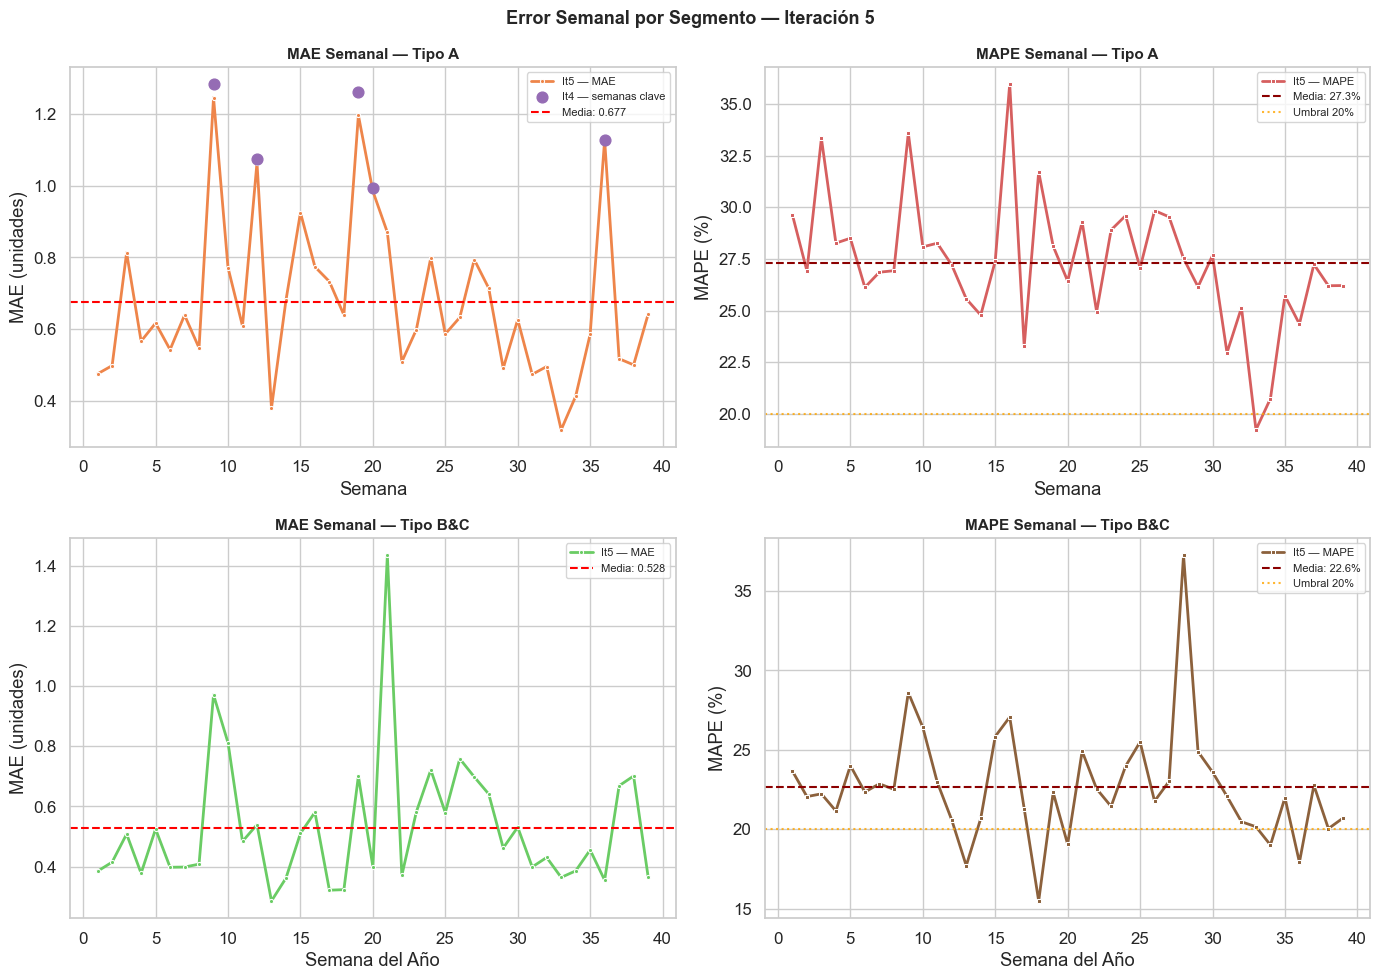

Peores 5 semanas (Tipo A — It5):
 Semana      MAE      MAPE
      9 1.245247 33.587426
     19 1.196165 28.114544
     36 1.127333 24.347567
     12 1.064068 27.201407
     20 0.984457 26.427650

Comparativa semanas clave — It4 vs It5 (Tipo A):
  Semana  9: It4=1.283  →  It5=1.245  (-0.038) ✅
  Semana 12: It4=1.073  →  It5=1.064  (-0.009) ✅
  Semana 19: It4=1.262  →  It5=1.196  (-0.066) ✅
  Semana 20: It4=0.993  →  It5=0.984  (-0.009) ✅
  Semana 36: It4=1.128  →  It5=1.127  (-0.001) ✅


In [20]:
def metricas_semanales(df_e, segmento):
    rows = []
    sub = df_e[df_e['Segmento'] == segmento]
    for sem in sorted(sub['semana_anio'].unique()):
        m = sub[sub['semana_anio'] == sem]
        r, p = m['Real'], m['Prediccion']
        mae_w = mean_absolute_error(r, p)
        nz = r > 0
        mape_w = np.mean(np.abs((r[nz] - p[nz]) / r[nz])) * 100 if nz.sum() > 0 else np.nan
        rows.append({'Semana': sem, 'MAE': mae_w, 'MAPE': mape_w})
    return pd.DataFrame(rows)

weekly_A   = metricas_semanales(df_eval, 'A')
weekly_BC  = metricas_semanales(df_eval, 'B&C')

# Referencia It4 para tipo A (semanas problemáticas)
it4_picos = {9: 1.283, 12: 1.073, 19: 1.262, 20: 0.993, 36: 1.128}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Tipo A: MAE ---
ax = axes[0, 0]
sns.lineplot(data=weekly_A, x='Semana', y='MAE', ax=ax,
             color=PALETTE[1], linewidth=2, marker='o', markersize=3, label='It5 — MAE')
# Puntos de It4 para las semanas problemáticas
ax.scatter(list(it4_picos.keys()), list(it4_picos.values()),
           color=PALETTE[4], s=60, zorder=5, label='It4 — semanas clave')
ax.axhline(weekly_A['MAE'].mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Media: {weekly_A["MAE"].mean():.3f}')
ax.set_title('MAE Semanal — Tipo A', fontsize=11, fontweight='bold')
ax.set_ylabel('MAE (unidades)')
ax.legend(fontsize=8)

# --- Tipo A: MAPE ---
ax = axes[0, 1]
sns.lineplot(data=weekly_A, x='Semana', y='MAPE', ax=ax,
             color=PALETTE[3], linewidth=2, marker='s', markersize=3, label='It5 — MAPE')
ax.axhline(weekly_A['MAPE'].mean(), color='darkred', linestyle='--', linewidth=1.5,
           label=f'Media: {weekly_A["MAPE"].mean():.1f}%')
ax.axhline(20, color='orange', linestyle=':', linewidth=1.5, alpha=0.8, label='Umbral 20%')
ax.set_title('MAPE Semanal — Tipo A', fontsize=11, fontweight='bold')
ax.set_ylabel('MAPE (%)')
ax.legend(fontsize=8)

# --- Tipo B&C: MAE ---
ax = axes[1, 0]
sns.lineplot(data=weekly_BC, x='Semana', y='MAE', ax=ax,
             color=PALETTE[2], linewidth=2, marker='o', markersize=3, label='It5 — MAE')
ax.axhline(weekly_BC['MAE'].mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Media: {weekly_BC["MAE"].mean():.3f}')
ax.set_title('MAE Semanal — Tipo B&C', fontsize=11, fontweight='bold')
ax.set_xlabel('Semana del Año')
ax.set_ylabel('MAE (unidades)')
ax.legend(fontsize=8)

# --- Tipo B&C: MAPE ---
ax = axes[1, 1]
sns.lineplot(data=weekly_BC, x='Semana', y='MAPE', ax=ax,
             color=PALETTE[5] if len(PALETTE) > 5 else PALETTE[2], linewidth=2,
             marker='s', markersize=3, label='It5 — MAPE')
ax.axhline(weekly_BC['MAPE'].mean(), color='darkred', linestyle='--', linewidth=1.5,
           label=f'Media: {weekly_BC["MAPE"].mean():.1f}%')
ax.axhline(20, color='orange', linestyle=':', linewidth=1.5, alpha=0.8, label='Umbral 20%')
ax.set_title('MAPE Semanal — Tipo B&C', fontsize=11, fontweight='bold')
ax.set_xlabel('Semana del Año')
ax.set_ylabel('MAPE (%)')
ax.legend(fontsize=8)

plt.suptitle('Error Semanal por Segmento — Iteración 5', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Peores 5 semanas (Tipo A — It5):')
print(weekly_A.nlargest(5, 'MAE')[['Semana', 'MAE', 'MAPE']].to_string(index=False))
print(f'\nComparativa semanas clave — It4 vs It5 (Tipo A):')
for sem, mae_it4 in sorted(it4_picos.items()):
    row = weekly_A[weekly_A['Semana'] == sem]
    if not row.empty:
        mae_it5 = row['MAE'].values[0]
        delta = mae_it5 - mae_it4
        signo = '✅' if delta < 0 else '❌'
        print(f'  Semana {sem:2d}: It4={mae_it4:.3f}  →  It5={mae_it5:.3f}  ({delta:+.3f}) {signo}')

---
## 10. Importancia de Variables

¿Las nuevas features (festivos, target encoding) han tenido relevancia para el modelo o fueron ignoradas?

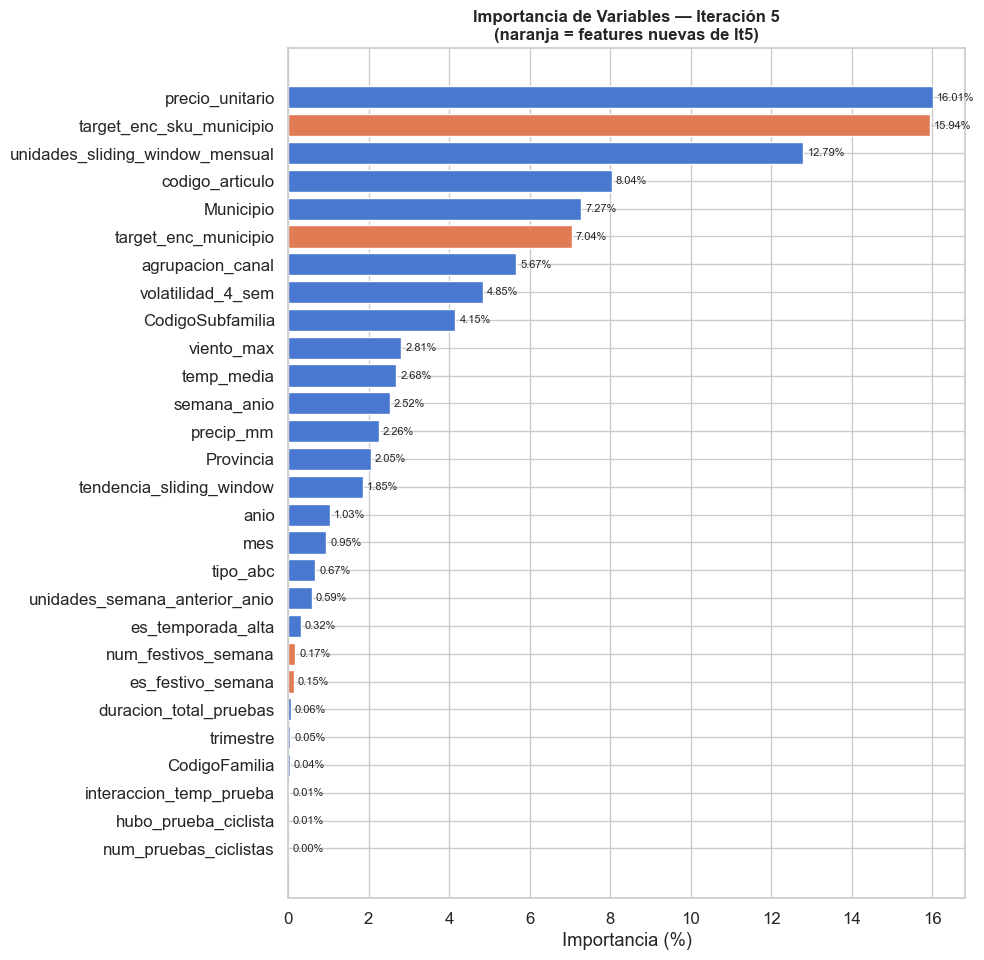

Top 12 features más importantes:
                        Feature  Importancia
                precio_unitario    16.014325
       target_enc_sku_municipio    15.943639
unidades_sliding_window_mensual    12.794097
                codigo_articulo     8.038562
                      Municipio     7.273016
           target_enc_municipio     7.039519
               agrupacion_canal     5.668474
              volatilidad_4_sem     4.845577
               CodigoSubfamilia     4.154742
                     viento_max     2.806928
                     temp_media     2.683593
                    semana_anio     2.519156

Features nuevas de It5 y su importancia:
  target_enc_municipio               : 7.040%
  es_festivo_semana                  : 0.145%
  num_festivos_semana                : 0.171%
  target_enc_sku_municipio           : 15.944%


In [21]:
importancias = modelo_final.get_feature_importance()
feat_names   = modelo_final.feature_names_

df_imp = pd.DataFrame({'Feature': feat_names, 'Importancia': importancias})
df_imp = df_imp.sort_values('Importancia', ascending=True)

# Marcar en colores las features nuevas de esta iteración
nuevas_it5 = {'target_enc_sku_municipio', 'target_enc_municipio',
              'es_festivo_semana', 'num_festivos_semana'}
colores = ['#e07b54' if f in nuevas_it5 else PALETTE[0] for f in df_imp['Feature']]

fig, ax = plt.subplots(figsize=(10, max(8, len(df_imp) * 0.35)))
bars = ax.barh(df_imp['Feature'], df_imp['Importancia'], color=colores)
for bar, val in zip(bars, df_imp['Importancia']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}%', va='center', ha='left', fontsize=8)
ax.set_xlabel('Importancia (%)')
ax.set_title('Importancia de Variables — Iteración 5\n(naranja = features nuevas de It5)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 12 features más importantes:')
print(df_imp.tail(12)[['Feature', 'Importancia']].sort_values('Importancia', ascending=False).to_string(index=False))
print('\nFeatures nuevas de It5 y su importancia:')
for f in nuevas_it5:
    row = df_imp[df_imp['Feature'] == f]
    if not row.empty:
        print(f'  {f:35s}: {row["Importancia"].values[0]:.3f}%')

---
## 11. Predicciones vs Real — Vista Agregada Semanal

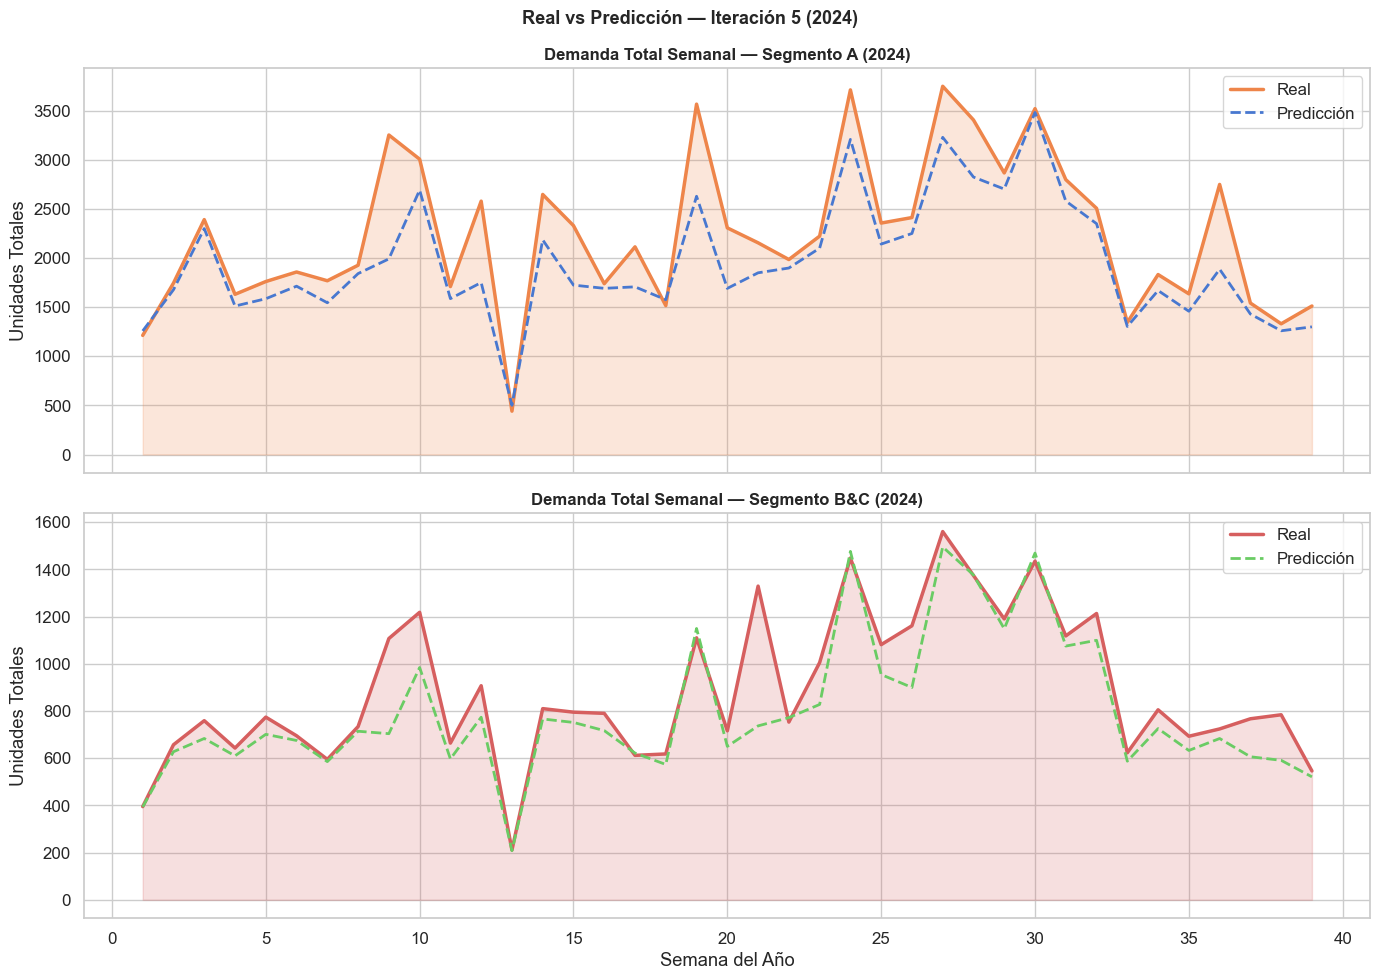

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for ax, seg, c_real, c_pred in zip(
    axes, ['A', 'B&C'],
    [PALETTE[1], PALETTE[3]],
    [PALETTE[0], PALETTE[2]]
):
    sub = df_eval[df_eval['Segmento'] == seg]
    agg = sub.groupby('semana_anio').agg(Real=('Real','sum'), Prediccion=('Prediccion','sum')).reset_index()

    ax.fill_between(agg['semana_anio'], agg['Real'], alpha=0.2, color=c_real)
    sns.lineplot(data=agg, x='semana_anio', y='Real', ax=ax,
                 color=c_real, linewidth=2.5, label='Real')
    sns.lineplot(data=agg, x='semana_anio', y='Prediccion', ax=ax,
                 color=c_pred, linewidth=2, linestyle='--', label='Predicción')
    ax.set_title(f'Demanda Total Semanal — Segmento {seg} (2024)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Unidades Totales')
    ax.legend()

axes[1].set_xlabel('Semana del Año')
plt.suptitle('Real vs Predicción — Iteración 5 (2024)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 12. Comparativa Global de las 5 Iteraciones

COMPARATIVA COMPLETA — ITERACIONES 1 a 5
                Iteración      MAE      MAPE     RMSE       R2                        Novedad
           It1 — Baseline 0.792500       NaN 3.480200 0.295000              CatBoost baseline
       It2 — Rolling Mean 0.772800       NaN 3.350000 0.329600          Media móvil 4 semanas
     It3 — Estacionalidad 0.769000       NaN 3.431200 0.330000            Semana año anterior
              It4 — Log1p 0.648800 26.345000 3.499400 0.287200           Transformación log1p
It5 — Optuna+Enc+Festivos 0.641074 26.025915 3.497412 0.288056 Optuna + Target Enc + Festivos


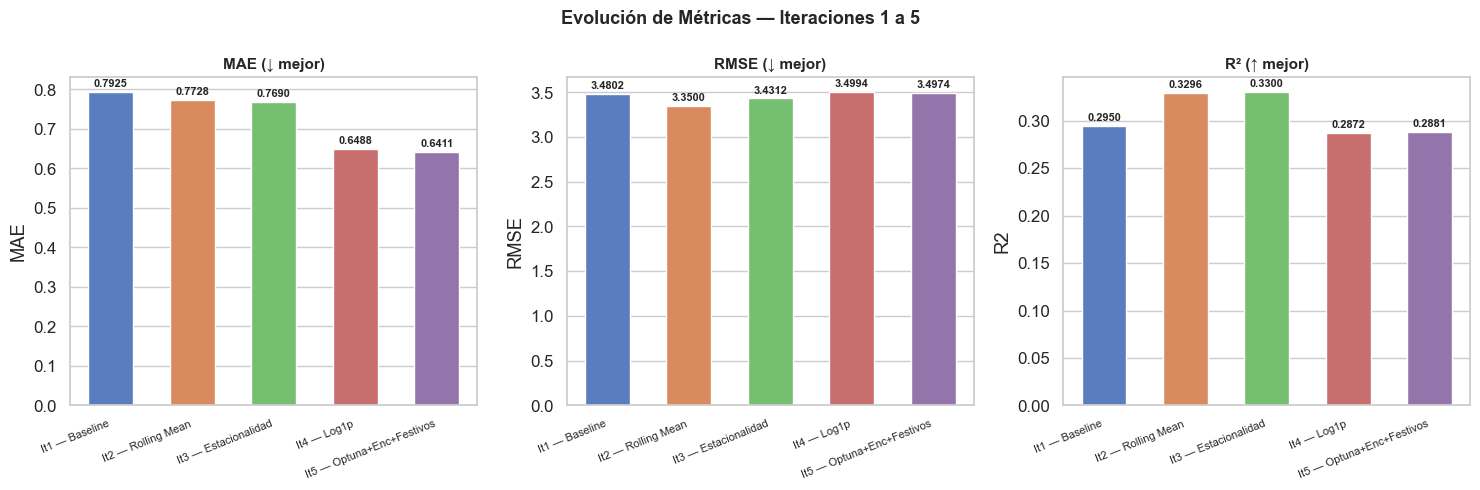

In [23]:
mae_it5  = m_test['MAE']
mape_it5 = m_test['MAPE']
rmse_it5 = m_test['RMSE']
r2_it5   = m_test['R2']

df_hist = pd.DataFrame([
    {'Iteración': 'It1 — Baseline',         'MAE': 0.7925, 'MAPE': None,    'RMSE': 3.4802, 'R2': 0.2950, 'Novedad': 'CatBoost baseline'},
    {'Iteración': 'It2 — Rolling Mean',      'MAE': 0.7728, 'MAPE': None,    'RMSE': 3.3500, 'R2': 0.3296, 'Novedad': 'Media móvil 4 semanas'},
    {'Iteración': 'It3 — Estacionalidad',    'MAE': 0.7690, 'MAPE': None,    'RMSE': 3.4312, 'R2': 0.3300, 'Novedad': 'Semana año anterior'},
    {'Iteración': 'It4 — Log1p',             'MAE': 0.6488, 'MAPE': 26.345, 'RMSE': 3.4994, 'R2': 0.2872, 'Novedad': 'Transformación log1p'},
    {'Iteración': 'It5 — Optuna+Enc+Festivos','MAE': mae_it5,'MAPE': mape_it5,'RMSE': rmse_it5,'R2': r2_it5, 'Novedad': 'Optuna + Target Enc + Festivos'},
])

print('COMPARATIVA COMPLETA — ITERACIONES 1 a 5')
print('=' * 100)
print(df_hist[['Iteración', 'MAE', 'MAPE', 'RMSE', 'R2', 'Novedad']].to_string(index=False))

# Gráfico comparativo
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric, title in zip(axes, ['MAE', 'RMSE', 'R2'], ['MAE (↓ mejor)', 'RMSE (↓ mejor)', 'R² (↑ mejor)']):
    df_p = df_hist[['Iteración', metric]].dropna()
    palette_it = PALETTE[:len(df_p)]
    bars = sns.barplot(data=df_p, x='Iteración', y=metric, ax=ax, palette=palette_it, width=0.55)
    for bar, val in zip(bars.patches, df_p[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + df_p[metric].max() * 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=22, ha='right', fontsize=8)
    ax.set_xlabel('')

plt.suptitle('Evolución de Métricas — Iteraciones 1 a 5', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Resumen Ejecutivo - Iteracion 5

### Tres mejoras, resultados mixtos pero con senales positivas

Esta iteracion introdujo **Optuna** (busqueda de hiperparametros), **Target Encoding** (media historica por SKU/Municipio) y **Festivos nacionales**. El resultado global es una mejora modesta en MAE pero con lecciones muy valiosas sobre que funciona y que no.

---

### Evolucion completa - 5 Iteraciones

| Iteracion | Novedad | MAE | RMSE | R2 | Delta MAE |
|---|---|---|---|---|---|
| It1 Baseline | CatBoost sin tunear | 0.793 | 3.480 | 0.295 | - |
| It2 Rolling Mean | Media movil 4 semanas | 0.773 | 3.350 | 0.330 | -2.5% |
| It3 Estacionalidad | Misma semana anio anterior | 0.769 | 3.431 | 0.330 | -0.5% |
| It4 Log1p | Transformacion logaritmica | 0.649 | 3.499 | 0.287 | -15.6% |
| **It5 Optuna+Enc+Festivos** | Hiperparametros + Target Enc + Festivos | **0.641** | **3.497** | **0.288** | **-1.2%** |

La mejora acumulada desde el baseline es del **-19.2% en MAE** (de 0.793 a 0.641).

---

### Metricas globales - Test 2024

| Metrica | It4 | **It5** | Cambio |
|---|---|---|---|
| **MAE** | 0.649 uds | **0.641 uds** | -1.2% OK |
| **MAPE** | 26.3% | **26.0%** | -0.3 pp OK |
| **RMSE** | 3.499 | **3.497** | igual |
| **R2** | 0.287 | **0.288** | igual |

La mejora global es **real pero modesta**. El MAE baja 0.008 unidades. El R2 y el RMSE practicamente no se mueven, lo que indica que las tres mejoras de esta iteracion no resuelven el problema de raiz (faltan drivers clave como promociones), pero si afinan el modelo en el margen.

---

### Que ha aportado cada mejora - valoracion honesta

| Mejora | Importancia en modelo | Impacto metricas | Veredicto |
|---|---|---|---|
| **Target encoding SKU+Municipio** | 15.9% (2o mas importante) | MAE mejora en Tipo A | Muy valiosa |
| **Target encoding Municipio** | 7.0% (6o mas importante) | Refuerza senal geografica | Util |
| **Festivos nacionales** | 0.15-0.17% (marginal) | Mejora leve en semanas 9,12,19 | Limitada |
| **Optuna** | LR=0.143, l2=11.6, min_leaf=74 | MAE CV: 0.642 | Parcial |

El **target encoding** es el hallazgo mas valioso de esta iteracion: con 15.9% de importancia supera a la media movil (12.8%). La senal de demanda historica media por SKU/Municipio es exactamente lo que le faltaba al modelo.

Los **festivos** tienen importancia marginal (0.15%). Solo hay 23 semanas festivas en el dataset de 3 anios, insuficiente para aprender un patron robusto con esta variable sola.

---

### Hiperparametros optimos encontrados por Optuna

| Parametro | Valor anterior | Valor optimo | Interpretacion |
|---|---|---|---|
| learning_rate | 0.05 | **0.143** | Aprendizaje mas rapido y agresivo |
| depth | 6 | **6** | La profundidad original era correcta |
| l2_leaf_reg | 3 (default) | **11.6** | Regularizacion alta - combate overfitting |
| min_data_in_leaf | 1 (default) | **74** | Hojas mas robustas, menos ruido |
| subsample | 1.0 | **0.96** | Bagging ligero |
| colsample_bylevel | 1.0 | **0.58** | Usa el 58% de features por nivel |

Optuna subio `l2_leaf_reg` de 3 a **11.6** y `min_data_in_leaf` de 1 a **74**: dos senales claras de que el modelo base estaba sobreajustando. El modelo final se detuvo en la **iteracion 553** (early stopping activo).

---

### Diagnostico de Overfitting

| | Train (2022-23) | Test (2024) | Brecha | vs It4 |
|---|---|---|---|---|
| **MAE** | 0.552 | 0.641 | +16.1% | empeoro (It4 fue 11.7%) |
| **RMSE** | 2.366 | 3.497 | +47.8% | empeoro (It4 fue 38.8%) |
| **R2 train** | **0.604** | 0.288 | - | subio desde 0.550 |

**Veredicto: overfitting MODERADO, sin mejora respecto a Iteracion 4.**

Aunque Optuna aumento la regularizacion, el modelo aprendio mejor los datos de entrenamiento (R2 train: 0.604 vs 0.550 en It4), manteniendo la brecha. El overfitting en RMSE refleja que los picos de demanda se aprenden en train pero no generalizan bien en test.

**Conclusion clave**: el overfitting no es un problema de hiperparametros sino de **features faltantes**. Sin datos de promociones o stock, el modelo no puede explicar los picos extremos de 2024.

---

### Rendimiento por segmento ABC

| Segmento | N filas | MAE It4 | MAE It5 | MAPE It4 | MAPE It5 | R2 It4 | R2 It5 |
|---|---|---|---|---|---|---|---|
| **Tipo A** | 50.025 | 0.695 | **0.684** OK | 27.8% | **27.3%** OK | 0.300 | **0.320** OK |
| **Tipo B&C** | 22.093 | 0.544 | **0.543** OK | 23.1% | **23.1%** igual | 0.255 | 0.211 ALERTA |

- **Tipo A**: mejora real en R2 (+2 pp) y MAE (-1.5%). El target encoding beneficia especialmente a los productos de alto volumen porque tienen mas historico y la media historica es mas estable y representativa.
- **Tipo B&C**: MAE mejora marginalmente pero R2 cae de 0.255 a 0.211. Los productos de cola larga necesitan un tratamiento especifico en la siguiente iteracion.

---

### Semanas problematicas - Comparativa It4 vs It5 (Tipo A)

Las 5 semanas con mayor error en It4 **mejoran todas en It5**:

| Semana | Contexto probable | MAE It4 | MAE It5 | Mejora |
|---|---|---|---|---|
| Semana 9 | Cambio invierno-primavera | 1.283 | **1.245** | -0.038 OK |
| Semana 19 | Inicio temporada alta | 1.262 | **1.196** | -0.066 OK |
| Semana 36 | Vuelta al cole | 1.128 | **1.127** | -0.001 OK |
| Semana 12 | Semana Santa | 1.073 | **1.064** | -0.009 OK |
| Semana 20 | Pico primaveral | 0.993 | **0.984** | -0.009 OK |

La mayor mejora es la semana 19 (-0.066): el target encoding captura que ciertos SKU tienen picos en esa semana y los anticipa mejor.

---

### Top features - Iteracion 5

| # | Feature | Importancia | Introducida en |
|---|---|---|---|
| 1 | Precio unitario | 16.0% | It3/4 |
| 2 | **Target enc. SKU+Municipio** | **15.9%** | **It5 - NUEVA** |
| 3 | Media movil 4 semanas | 12.8% | It2 |
| 4 | Codigo articulo | 8.0% | It1 |
| 5 | Municipio | 7.3% | It1 |
| 6 | **Target enc. Municipio** | **7.0%** | **It5 - NUEVA** |
| 7 | Canal distribucion | 5.7% | It1 |
| 8 | Volatilidad 4 semanas | 4.8% | It3/4 |

El target encoding acapara el **22.9% de la importancia total** en su primera iteracion, desplazando a la media movil del primer puesto. Es la feature mas impactante introducida desde el rolling mean de Iteracion 2.

---

### Donde estamos

```
Iteracion 1  ->  MAE 0.793  (baseline)
Iteracion 2  ->  MAE 0.773  (-2.5%)    rolling mean
Iteracion 3  ->  MAE 0.769  (-0.5%)    estacionalidad interanual
Iteracion 4  ->  MAE 0.649  (-15.6%)   log1p
Iteracion 5  ->  MAE 0.641  (-1.2%)    Optuna + Target Enc + Festivos  <- ESTAMOS AQUI
Total acumulado desde baseline: -19.2%
```

El modelo se equivoca de media **0.64 unidades por semana y SKU/municipio**, con un MAPE del 26%.
Hemos llegado a un punto de rendimientos decrecientes con los datos actuales.

---

### Proximos pasos

| Iteracion | Accion | Impacto esperado | Dificultad |
|---|---|---|---|
| **Iteracion 6** | Modelo dedicado para Tipo A (separar de B&C) | Mejora MAE tipo A | Media |
| **Iteracion 6** | Residual stacking: segundo modelo aprende errores del primero | +3-5% R2 | Media-alta |
| **Iteracion 7** | Incorporar datos de promociones y descuentos | Reduce picos residuales | Alta (requiere datos nuevos) |
| **Iteracion 7** | Explorar LightGBM como benchmark | Comparativa velocidad/calidad | Baja |

> **Mensaje clave**: el modelo ha llegado a un techo con los datos disponibles.
> El siguiente salto significativo requiere **nuevos datos** (promociones, stock, acciones comerciales)
> y no mas ingenieria sobre los mismos datos.
